# Classifier

In [2]:
import re
import matplotlib.pyplot as plt

def extract_accuracies(log_path):
    """
    Extracts per-epoch train and test accuracies from a log file.

    Parameters:
        log_path (str): Path to the log file.

    Returns:
        epochs (list[int]), train_acc (list[float]), test_acc (list[float])
    """
    pattern = re.compile(r"\[\s*(\d+)\]\s+train:\s+([\d.]+)%\s+test:\s+([\d.]+)%")
    epochs, train_acc, test_acc = [], [], []

    with open(log_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                epoch = int(match.group(1))
                train = float(match.group(2))
                test = float(match.group(3))
                epochs.append(epoch)
                train_acc.append(train)
                test_acc.append(test)

    return epochs, train_acc, test_acc

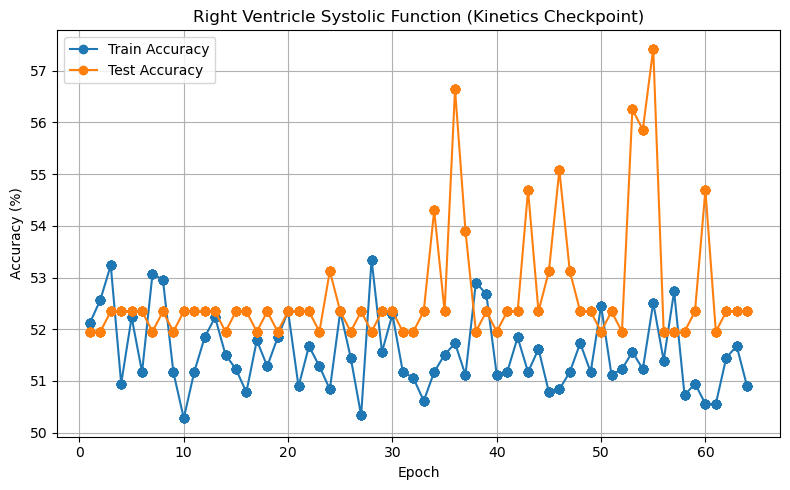

In [10]:
log_file1 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_kinetics_0812_v1.log"
epochs1, train_acc1, test_acc1 = extract_accuracies(log_file1)
title="Right Ventricle Systolic Function (Kinetics Checkpoint)"
plt.figure(figsize=(8, 5))
plt.plot(epochs1, train_acc1, label="Train Accuracy", marker="o")
plt.plot(epochs1, test_acc1, label="Test Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(title)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### RVFX, Cooldown

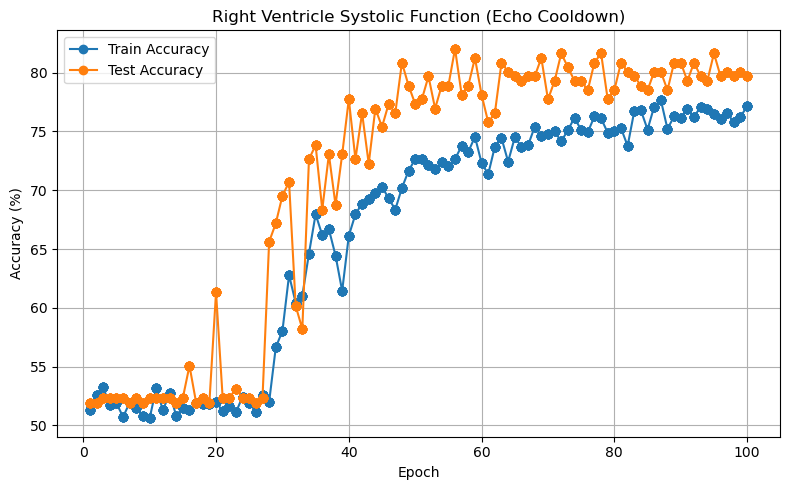

In [31]:
log_file1 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_0812_v1.log"
epochs1, train_acc1, test_acc1 = extract_accuracies(log_file1)
title="Right Ventricle Systolic Function (Echo Cooldown)"
plt.figure(figsize=(8, 5))
plt.plot(epochs1, train_acc1, label="Train Accuracy", marker="o")
plt.plot(epochs1, test_acc1, label="Test Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(title)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### RVFX, Pretrained for 9 Epochs (Loss=0.455)

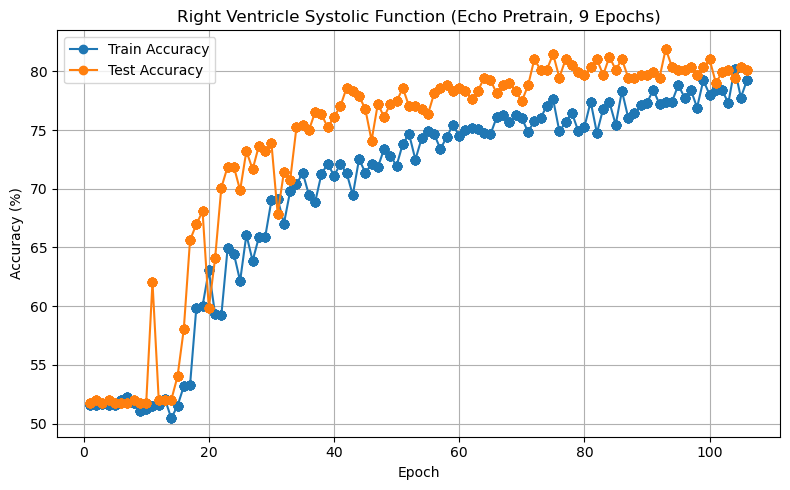

In [32]:
log_file1 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe9.log"
epochs1, train_acc1, test_acc1 = extract_accuracies(log_file1)
title="Right Ventricle Systolic Function (Echo Pretrain, 9 Epochs)"
plt.figure(figsize=(8, 5))
plt.plot(epochs1, train_acc1, label="Train Accuracy", marker="o")
plt.plot(epochs1, test_acc1, label="Test Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(title)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

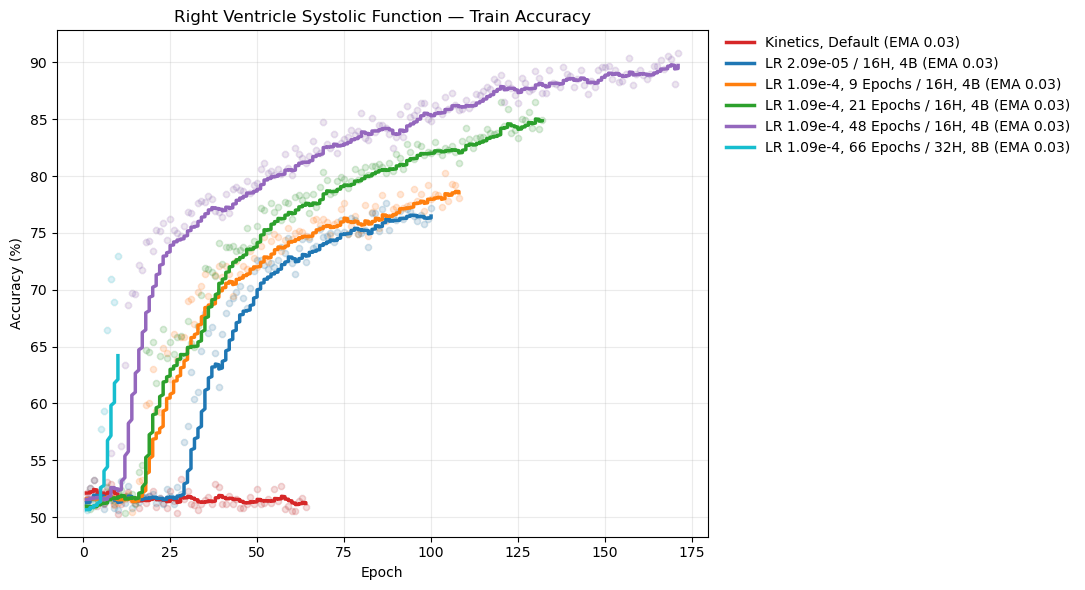

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def ema(values, alpha=0.15):
    s = None
    out = []
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# --- Parse logs ---
log_cool = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_0812_v1.log"
e1, tr1, te1 = extract_accuracies(log_cool)

log_pre9 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe9.log"
e2, tr2, te2 = extract_accuracies(log_pre9)

log_pre21 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe21.log"
e3, tr3, te3 = extract_accuracies(log_pre21)

log_pre48 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe48.log"
e4, tr4, te4 = extract_accuracies(log_pre48)

log_kin = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_kinetics_0812_v1.log"
e5, tr5, te5 = extract_accuracies(log_kin)

log_pre66 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h32_b8_0820_keepe66.log"
e6, tr6, te6 = extract_accuracies(log_pre66)

# ---- Plot Train-only, with raw (faint dots) + EMA (solid line) ----
alpha = 0.03  # EMA smoothing
dot_alpha = 0.02
dot_size = 20

colors = {
    "cooldown": "#1f77b4",   # blue
    "pre9":     "#ff7f0e",   # orange
    "pre21":    "#2ca02c",   # green
    "pre48":    "#9467bd",   # purple
    "kin":      "#d62728",   # red
    "pre66":    "#17becf"    # cyan
}

plt.figure(figsize=(11, 6))

# Kinetics checkpoint
plt.scatter(e5, tr5, s=dot_size, color=colors["kin"], alpha=dot_alpha)
plt.plot(e5, ema(tr5, alpha), linewidth=2.5, color=colors["kin"], label=f"Kinetics, Default (EMA {alpha})")

# Cooldown
plt.scatter(e1, tr1, s=dot_size, color=colors["cooldown"], alpha=dot_alpha)
plt.plot(e1, ema(tr1, alpha), linewidth=2.5, color=colors["cooldown"], label=f"LR 2.09e-05 / 16H, 4B (EMA {alpha})")

# Pretrain keepe9
plt.scatter(e2, tr2, s=dot_size, color=colors["pre9"], alpha=dot_alpha)
plt.plot(e2, ema(tr2, alpha), linewidth=2.5, color=colors["pre9"], label=f"LR 1.09e-4, 9 Epochs / 16H, 4B (EMA {alpha})")

# Pretrain keepe21
plt.scatter(e3, tr3, s=dot_size, color=colors["pre21"], alpha=dot_alpha)
plt.plot(e3, ema(tr3, alpha), linewidth=2.5, color=colors["pre21"], label=f"LR 1.09e-4, 21 Epochs / 16H, 4B (EMA {alpha})")

# Pretrain keepe48
plt.scatter(e4, tr4, s=dot_size, color=colors["pre48"], alpha=dot_alpha)
plt.plot(e4, ema(tr4, alpha), linewidth=2.5, color=colors["pre48"], label=f"LR 1.09e-4, 48 Epochs / 16H, 4B (EMA {alpha})")

# Pretrain keepe66
plt.scatter(e6, tr6, s=dot_size, color=colors["pre66"], alpha=dot_alpha)
plt.plot(e6, ema(tr6, alpha), linewidth=2.5, color=colors["pre66"], label=f"LR 1.09e-4, 66 Epochs / 32H, 8B (EMA {alpha})")

# ---- Formatting ----
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Right Ventricle Systolic Function — Train Accuracy")
plt.grid(True, alpha=0.25)

# Legend outside
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False)

# Nice y-limits
ymin = min(min(tr1), min(tr2), min(tr3), min(tr4), min(tr5), min(tr6))
ymax = max(max(tr1), max(tr2), max(tr3), max(tr4), max(tr5), max(tr6))
plt.ylim(ymin - 2, ymax + 2)

plt.tight_layout()
plt.show()


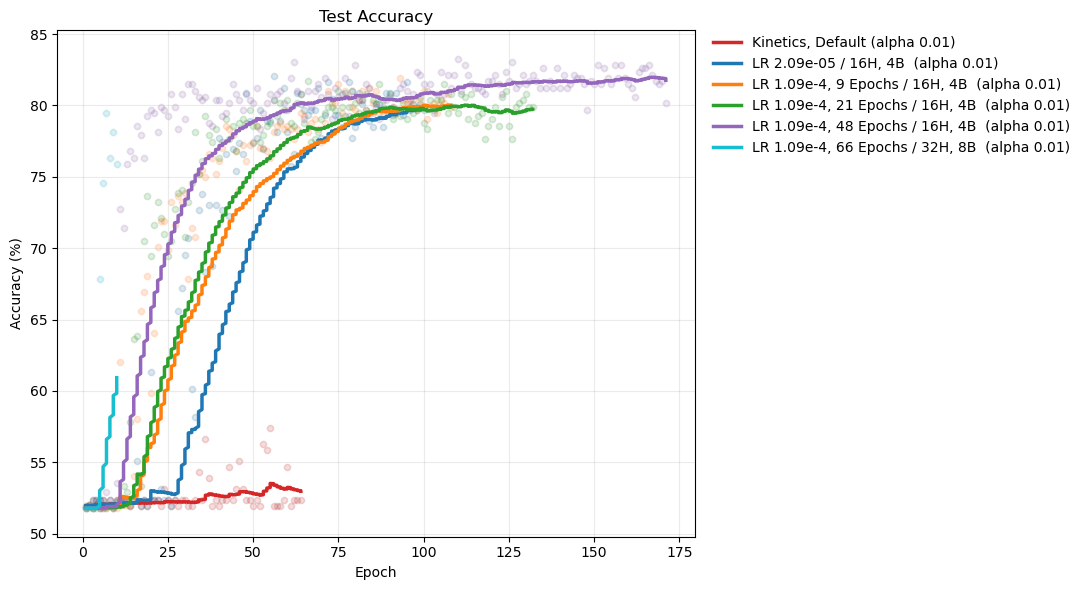

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def ema(values, alpha=0.15):
    s = None
    out = []
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# --- Parse logs ---
log_cool = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_0812_v1.log"
e1, tr1, te1 = extract_accuracies(log_cool)

log_pre9 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe9.log"
e2, tr2, te2 = extract_accuracies(log_pre9)

log_pre21 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe21.log"
e3, tr3, te3 = extract_accuracies(log_pre21)

log_pre48 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h16_b4_0820_keepe48.log"
e4, tr4, te4 = extract_accuracies(log_pre48)

log_kin = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_kinetics_0812_v1.log"
e5, tr5, te5 = extract_accuracies(log_kin)

log_pre66 = "/home/sagemaker-user/user-default-efs/vjepa2/rvfx_cooldown_h32_b8_0820_keepe66.log"
e6, tr6, te6 = extract_accuracies(log_pre66)

# ---- Plot Test-only, with raw (faint dots) + EMA (solid line) ----
alpha = 0.01  # EMA smoothing
dot_alpha = 0.02
dot_size = 20

colors = {
    "cooldown": "#1f77b4",   # blue
    "pre9":     "#ff7f0e",   # orange
    "pre21":    "#2ca02c",   # green
    "pre48":    "#9467bd",   # purple
    "kin":      "#d62728",   # red
    "pre66":    "#17becf"    # cyan
}

plt.figure(figsize=(11, 6))

# Kinetics checkpoint
plt.scatter(e5, te5, s=dot_size, color=colors["kin"], alpha=dot_alpha)
plt.plot(e5, ema(te5, alpha), linewidth=2.5, color=colors["kin"], label=f"Kinetics, Default (alpha {alpha})")

# Cooldown
plt.scatter(e1, te1, s=dot_size, color=colors["cooldown"], alpha=dot_alpha)
plt.plot(e1, ema(te1, alpha), linewidth=2.5, color=colors["cooldown"], label=f"LR 2.09e-05 / 16H, 4B  (alpha {alpha})")

# Pretrain keepe9
plt.scatter(e2, te2, s=dot_size, color=colors["pre9"], alpha=dot_alpha)
plt.plot(e2, ema(te2, alpha), linewidth=2.5, color=colors["pre9"], label=f"LR 1.09e-4, 9 Epochs / 16H, 4B  (alpha {alpha})")

# Pretrain keepe21
plt.scatter(e3, te3, s=dot_size, color=colors["pre21"], alpha=dot_alpha)
plt.plot(e3, ema(te3, alpha), linewidth=2.5, color=colors["pre21"], label=f"LR 1.09e-4, 21 Epochs / 16H, 4B  (alpha {alpha})")

# Pretrain keepe48
plt.scatter(e4, te4, s=dot_size, color=colors["pre48"], alpha=dot_alpha)
plt.plot(e4, ema(te4, alpha), linewidth=2.5, color=colors["pre48"], label=f"LR 1.09e-4, 48 Epochs / 16H, 4B  (alpha {alpha})")

# Pretrain keepe66
plt.scatter(e6, te6, s=dot_size, color=colors["pre66"], alpha=dot_alpha)
plt.plot(e6, ema(te6, alpha), linewidth=2.5, color=colors["pre66"], label=f"LR 1.09e-4, 66 Epochs / 32H, 8B  (alpha {alpha})")

# ---- Formatting ----
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.grid(True, alpha=0.25)

# Legend outside
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False)

# Nice y-limits
ymin = min(min(te1), min(te2), min(te3), min(te4), min(te5), min(te6))
ymax = max(max(te1), max(te2), max(te3), max(te4), max(te5), max(te6))
plt.ylim(ymin - 2, ymax + 2)

plt.tight_layout()
plt.show()


# Pacemaker

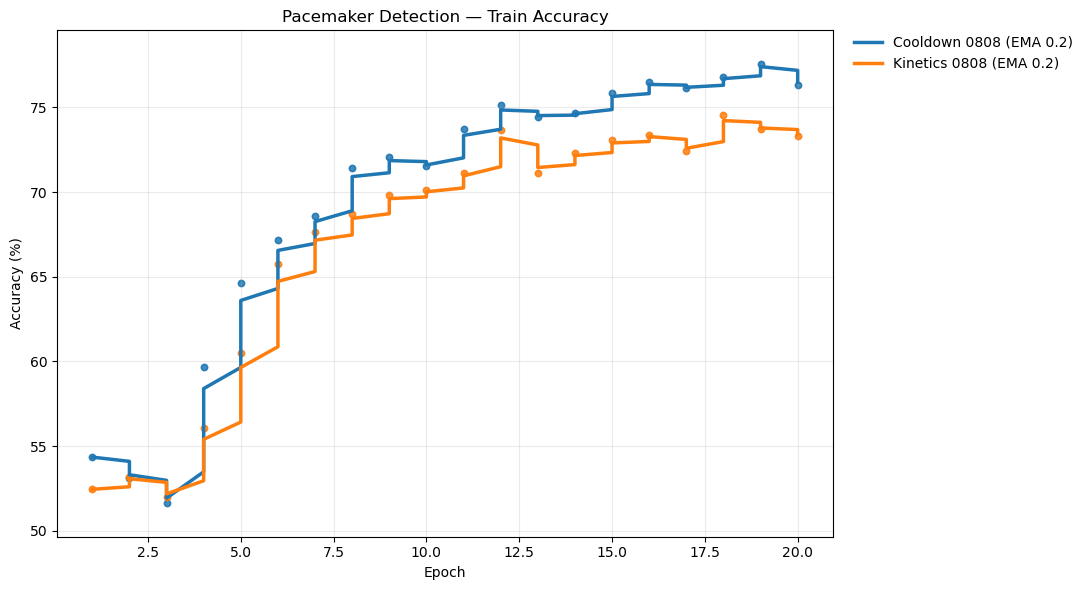

In [87]:
import matplotlib.pyplot as plt
import os

def ema(values, alpha=0.03):
    s = None
    out = []
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# --- Configure pacemaker runs ---
BASE = "/home/sagemaker-user/user-default-efs/vjepa2"
runs = [
    (os.path.join(BASE, "pacemaker_cooldown_0808_v1.log"), "Cooldown 0808"),
    # (os.path.join(BASE, "pacemaker_cooldown_0809_v2.log"), "Cooldown 0809 v2"),
    # (os.path.join(BASE, "pacemaker_cooldown_v2.log"),     "Cooldown v2"),
    (os.path.join(BASE, "pacemaker_kinetics_0808_v1.log"),"Kinetics 0808"),
    # (os.path.join(BASE, "pacemaker_kinetics_0809_v2.log"),"Kinetics 0809 v2"),
]

# Fixed colors per run
palette = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#d62728",  # red
]

EMA_ALPHA = 0.2   # smoothing for EMA
DOT_ALPHA = 0.2    # opacity for raw dots
DOT_SIZE  = 20

plt.figure(figsize=(11, 6))

mins, maxs = [], []

for (path, label), color in zip(runs, palette):
    if not os.path.exists(path):
        print(f"Warning: missing {path}, skipping.")
        continue
    epochs, train_acc, test_acc = extract_accuracies(path)

    # Raw dots (faint)
    plt.scatter(epochs, train_acc, s=DOT_SIZE, color=color, alpha=DOT_ALPHA)

    # EMA line (opaque)
    plt.plot(epochs, ema(train_acc, EMA_ALPHA), linewidth=2.5, color=color, label=f"{label} (EMA {EMA_ALPHA})")

    mins.append(min(train_acc))
    maxs.append(max(train_acc))

# --- Formatting ---
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Pacemaker Detection — Train Accuracy")
plt.grid(True, alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False)

if mins and maxs:
    plt.ylim(min(mins) - 2, max(maxs) + 2)

plt.tight_layout()
plt.show()


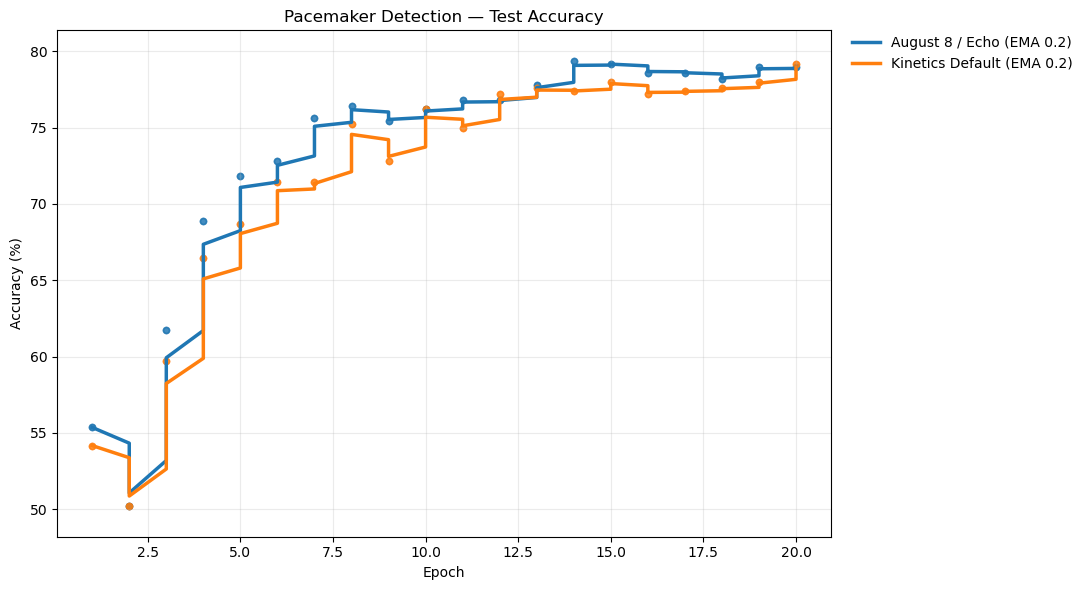

In [97]:
import matplotlib.pyplot as plt
import os

def ema(values, alpha=0.03):
    s = None
    out = []
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# Reuse your existing parser
# def extract_accuracies(log_path): -> returns (epochs, train_acc, test_acc)

# --- Configure pacemaker runs ---
BASE = "/home/sagemaker-user/user-default-efs/vjepa2"
runs = [
    (os.path.join(BASE, "pacemaker_cooldown_0808_v1.log"), "August 8 / Echo"),
    # (os.path.join(BASE, "pacemaker_cooldown_0809_v2.log"), "Cooldown 0809 v2"),
    # (os.path.join(BASE, "pacemaker_cooldown_v2.log"),     "Cooldown v2"),
    (os.path.join(BASE, "pacemaker_kinetics_0808_v1.log"),"Kinetics Default"),
    # (os.path.join(BASE, "pacemaker_kinetics_0809_v2.log"),"Kinetics 0809 v2"),
]

# Fixed colors per run (dots + EMA share color; dots are translucent)
palette = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#9467bd",  # purple
    "#d62728",  # red
]

EMA_ALPHA = 0.2   # smoothing for EMA
DOT_ALPHA = 0.2    # opacity for raw dots
DOT_SIZE  = 20

plt.figure(figsize=(11, 6))

mins, maxs = [], []

for (path, label), color in zip(runs, palette):
    if not os.path.exists(path):
        print(f"Warning: missing {path}, skipping.")
        continue
    epochs, train_acc, test_acc = extract_accuracies(path)

    # Raw dots (faint)
    plt.scatter(epochs, test_acc, s=DOT_SIZE, color=color, alpha=DOT_ALPHA)

    # EMA line (opaque)
    plt.plot(epochs, ema(test_acc, EMA_ALPHA), linewidth=2.5, color=color, label=f"{label} (EMA {EMA_ALPHA})")

    mins.append(min(test_acc))
    maxs.append(max(test_acc))

# --- Formatting ---
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Pacemaker Detection — Test Accuracy")
plt.grid(True, alpha=0.25)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0., frameon=False)

if mins and maxs:
    plt.ylim(min(mins) - 2, max(maxs) + 2)

plt.tight_layout()
plt.show()


# Pretraining

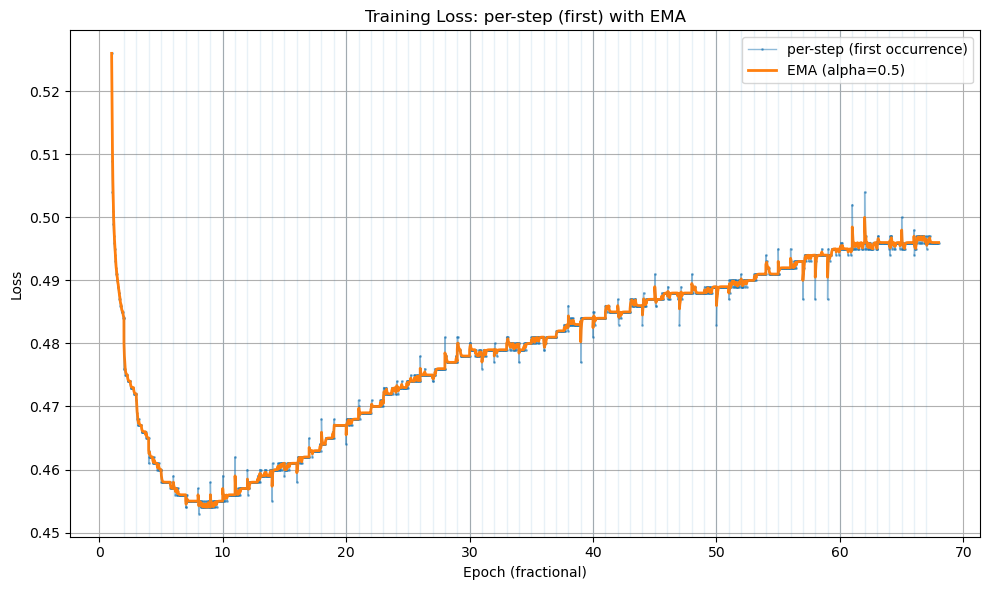

In [7]:
import re
from collections import OrderedDict
import numpy as np
import matplotlib.pyplot as plt

# Paths to both logs
LOG_FILES = [
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep0-34-0820.log",
    "/home/sagemaker-user/user-default-efs/vjepa2/pretrain-echo-336px-16f-ep34-100-0820.log"
]

ALPHA = 0.5  # EMA smoothing factor

# Regex for step losses
STEP_PAT = re.compile(r"\[(\d+),\s*(\d+)\]\s+loss:\s+([0-9]*\.?[0-9]+)")

def extract_first_loss_per_step(log_path):
    """
    Return list of (epoch, step, loss) for the FIRST occurrence of each (epoch, step).
    """
    first = OrderedDict()
    with open(log_path, "r") as f:
        for line in f:
            m = STEP_PAT.search(line)
            if not m:
                continue
            e, s, l = int(m.group(1)), int(m.group(2)), float(m.group(3))
            key = (e, s)
            if key not in first:
                first[key] = l
    return [(e, s, l) for (e, s), l in first.items()]

def ema(values, alpha=0.01):
    """Exponential moving average (continuous across the run)."""
    out, s = [], None
    for v in values:
        s = v if s is None else alpha * v + (1 - alpha) * s
        out.append(s)
    return out

# ---- parse both logs and combine ----
all_records = []
for path in LOG_FILES:
    all_records.extend(extract_first_loss_per_step(path))

# sort by epoch, step
all_records = sorted(all_records, key=lambda x: (x[0], x[1]))
epochs, steps, losses = zip(*all_records)

# fractional epoch x-axis
max_step = max(steps)
x_steps = [e + s / (max_step + 1.0) for e, s in zip(epochs, steps)]

# compute EMA
losses_ema = ema(losses, alpha=ALPHA)

# ---- plot ----
plt.figure(figsize=(10, 6))
plt.plot(
    x_steps, losses,
    marker=".", linestyle="-",
    linewidth=1, markersize=2,
    alpha=0.5,
    # color="#808080",   # gray per-step
    label="per-step (first occurrence)"
)
plt.plot(
    x_steps, losses_ema,
    linewidth=2,
    # color="#1f77b4",   # blue EMA
    label=f"EMA (alpha={ALPHA})"
)

# epoch boundary lines
for e in sorted(set(epochs))[1:]:
    plt.axvline(e, alpha=0.1, linewidth=1)

plt.xlabel("Epoch (fractional)")
plt.ylabel("Loss")
plt.title("Training Loss: per-step (first) with EMA")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
